## Geometric Design Principles of Protocell Division: The Volumetric Penalty
Synthetic division is often viewed as a problem of membrane bending. Here, we analyze it as a topological constraint problem. We show that a "Geometric Lock" makes spherical division energetically prohibitive, while rod-shaped geometries provide a "Surface-to-Volume Slack" that enables low-energy fission. This suggests that rod-like elongation is not just a growth phase, but a functional design requirement for robust cell division.

### 1. The Design Principle: Volume-Area Coupling
In the absence of de novo lipid synthesis, the total membrane area $A_{tot}$ remains constant. For a division into two identical daughter spheres ($n=2$), the radius of each daughter $R_d$ is constrained by:$$A_{tot} = 2 \cdot (4\pi R_d^2) \implies R_d = \sqrt{\frac{A_{tot}}{8\pi}}$$

The geometry of the cell dictates its thermodynamic state. We use the Reduced Volume ($v$) to define the "fullness" of the system:
$$v = \frac{V}{\frac{4}{3}\pi (A_{tot}/4\pi)^{3/2}}$$

### 1.1 The Spherical "Geometric Lock" ($v=1$)
A parent sphere with the same area $A_{tot}$ has a radius $R_p = \sqrt{A_{tot}/4\pi}$ and volume $V_p = \frac{4}{3}\pi R_p^3$. The total volume of the two daughter spheres is:$$V_{daughters} = 2 \cdot \frac{4}{3}\pi R_d^3 = 2 \cdot \frac{4}{3}\pi \left( \frac{R_p}{\sqrt{2}} \right)^3 = \frac{1}{\sqrt{2}} V_p \approx 0.707 V_p$$This necessitates a $\sim 29.3\%$ reduction in internal volume.

### 1.2 The Rod-shaped "Topological Flexibility" ($v < 1$)
In contrast, rod-shaped (prolate) cells start with $v < 1$. This "Geometric Slack" allows the Z-ring to achieve fission by redistributing area rather than forcing volume displacement, drastically lowering the energy cost.

### 2. Modeling the Work of Division
We define the active work $\mathcal{W}(\xi)$ performed by the contractile machinery as the energy required to overcome the internal osmotic pressure $P$ during fluid expulsion. Assuming a linear elastic response for the osmotic penalty, $P(V) = \mathcal{K}(V_{init} - V)$, the accumulated work along the reaction coordinate $\xi \in [0, 1]$ is:$$\mathcal{W}(\xi) = \int_{0}^{\Delta V \cdot \xi} \mathcal{K} \cdot \delta V \, d(\delta V) = \frac{1}{2} \mathcal{K} (\Delta V \cdot \xi)^2$$

Where:
- $\Delta V = V_{init} - V_{final}$ is the Total Volumetric Penalty.
- $\delta V = \Delta V \cdot \xi$ is the Instantaneous volume displaced at progress $\xi$.

In our model, we track two distinct metrics to describe the "difficulty" of division:

Volumetric Displacement ($\Delta V$): This is the absolute amount of fluid (in normalized units) that the Z-ring must force out of the cell to reach the final state (two daughter spheres).$$\Delta V = V_{initial} - V_{final}$$Volume Loss %: This is the relative penalty. It measures how much of the parent's original "living space" is sacrificed to satisfy the constant surface area constraint.

$$\text{Loss } \% = \left( \frac{V_{initial} - V_{final}}{V_{initial}} \right) \times 100\%$$

### 3. Quantitative Comparison
We calculate the work required $\mathcal{W}$ for both Spherical and Rod-shaped precursors to reach the same functional end-state: two daughter vesicles.

#### Imports and Configuration

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Publication Quality Settings ---
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Arial',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 150
})

# --- Parameters ---
K_bulk = 1000.0  # Osmotic penalty coefficient (P = K * dV)
A_total = 100.0     # Total lipid surface area (constant)

#### Constants and Geometric Definitions

In [3]:
# Progress: 0 (Initial state) to 1 (Complete fission)
progress = np.linspace(0, 1, 100)

# 1. Spherical Case
R_sphere = np.sqrt(A_total / (4 * np.pi))
V_sphere_init = (4/3) * np.pi * R_sphere**3

# 2. Rod Case ( Aspect Ratio 3:1)
# Derived from area of a cylinder with hemispherical caps
R_rod = np.sqrt(A_total / (8 * np.pi))
V_rod_init = np.pi * R_rod**2 * (2*R_rod) + (4/3) * np.pi * R_rod**3

# 3. Target End-State (Two identical daughter spheres)
# Each sphere has Area = A_total / 2
R_daughter = np.sqrt((A_total / 2) / (4 * np.pi))
V_final_total = 2 * (4/3) * np.pi * R_daughter **3

#### Thermodynamic Calculations

In [4]:
# The volumetric displacement required
dV_sphere = V_sphere_init - V_final_total
dV_rod = V_rod_init - V_final_total

# Work = 0.5 * K * (delta_V)^2
W_sphere = 0.5 * K_bulk * (dV_sphere * progress)**2
W_rod = 0.5 * K_bulk * (dV_rod * progress)**2

print(f"Volume reduction required for Sphere: {dV_sphere/V_sphere_init*100:.2f}%")
print(f"Volume reduction required for Rod: {dV_rod/V_rod_init*100:.2f}%")

Volume reduction required for Sphere: 29.29%
Volume reduction required for Rod: 20.00%


#### Visualization

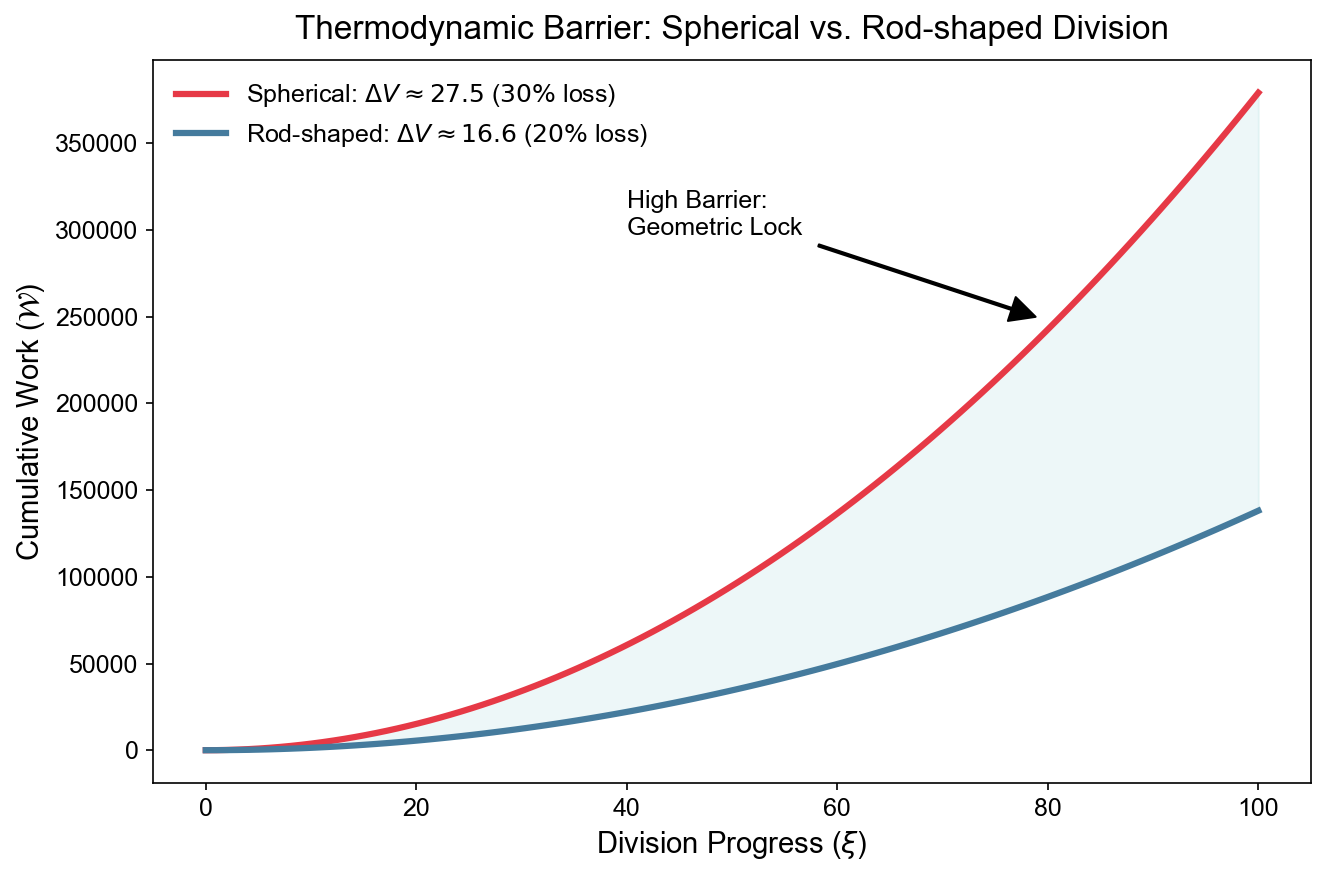

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

# Use raw strings (r) for labels with backslashes
ax.plot(progress * 100, W_sphere, color='#E63946', lw=3, label=rf'Spherical: $\Delta V \approx {dV_sphere:.1f}$ ($30\%$ loss)')
ax.plot(progress * 100, W_rod, color='#457B9D', lw=3, label=rf'Rod-shaped: $\Delta V \approx {dV_rod:.1f}$ ($20\%$ loss)')

# Highlight the "Geometric Lock" region
ax.fill_between(progress * 100, W_sphere, W_rod, color='#A8DADC', alpha=0.2)

ax.set_title("Thermodynamic Barrier: Spherical vs. Rod-shaped Division", pad=10)
ax.set_xlabel(r"Division Progress ($\xi$)")
ax.set_ylabel(r"Cumulative Work ($\mathcal{W}$)")

ax.legend(frameon=False)

plt.annotate('High Barrier:\nGeometric Lock', xy=(80, W_sphere[80]), xytext=(40, W_sphere[80]*1.2),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

### 4. Discussion: Why Form Follows Function
- Robustness via Geometry: Rod-shaped geometry is not an arbitrary evolutionary choice but a physical strategy to decouple cytokinesis from osmotic stress.

- The Energetic Threshold: In spherical division, the volumetric work ($\sim 10^4 k_B T$) is orders of magnitude higher than membrane bending energy ($\sim 10^2 k_B T$). This makes volume displacement the "rate-limiting" physical step.

- Experimental Prediction: Successful synthetic division requires either lipid supply (to increase $A_{tot}$) or morphological pre-adaptation (to decrease $v$). Attempting to divide a purely spherical vesicle will likely lead to lysis due to the massive pressure spike.